# HFO Evaluation on Real-Time sEEG Data using an snn-torch-trained Network

## Check WD (change if necessary) and file loading

In [15]:
# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)

# Check if the current WD is the file location
if "/thesis-lava/src/nir" not in os.getcwd():
    # Set working directory to this file location
    file_location = f"{os.getcwd()}/thesis-lava/src/nir"
    print("File Location: ", file_location)

    # Change the current working Directory
    os.chdir(file_location)

    # New Working Directory
    print("New Working Directory: ", os.getcwd())

/home/monkin/Desktop/feup/thesis/thesis-lava/src/nir


## Load the Network from the `NIR` file

In [16]:
import numpy as np
import nir
import matplotlib.pyplot as plt

# Load the Trained Network from the NIR File
NIR_FILENAME = "fr_median_trained_net.nir"

nir_network = nir.read(f"models/{NIR_FILENAME}")

In [17]:
# Print the network summary
print(f"NIR Network Info: Nº Nodes: {len(nir_network.nodes)} | Nº Edges: {len(nir_network.edges)}")

print(nir_network.nodes)
print(nir_network.edges)

NIR Network Info: Nº Nodes: 8 | Nº Edges: 7
{'fc3': Linear(weight=array([[-1.11489333e-01, -2.68412918e-01, -3.24451417e-01,
         6.16860867e-01, -3.27180773e-01, -2.12263197e-01,
        -1.17689617e-01, -2.33668327e-01,  5.08770943e-01,
        -4.38423663e-01,  4.84119266e-01,  5.60897887e-01,
        -3.88121665e-01,  6.27892852e-01,  2.49766069e-03,
         4.52961385e-01, -9.30073857e-02,  6.34308040e-01,
         6.06913209e-01, -4.26406972e-02,  9.06697035e-01,
         5.93553901e-01, -3.50169949e-02, -8.73716474e-02],
       [ 4.99247432e-01, -1.59530684e-01, -4.45856247e-03,
         7.08272755e-01,  4.83858675e-01,  4.60404038e-01,
         8.41623485e-01,  4.03165221e-01, -4.95698377e-02,
        -1.76092297e-01, -1.59834176e-01,  5.57745457e-01,
         4.06628132e-01,  5.90626299e-01,  4.01989132e-01,
         4.52161670e-01,  5.40686071e-01,  4.61366415e-01,
         5.68166554e-01, -1.86424062e-01, -4.92532272e-03,
         5.76662421e-01, -6.11825660e-02, -2.090

### Analyze individual Layers of the imported Network

In [18]:
nirLIF1 = nir_network.nodes["lif1"]
print(nirLIF1)

CubaLIF(tau_syn=array([0.00027337, 0.00020684, 0.00029694, 0.0001266 , 0.00028942,
       0.00017805, 0.00018086, 0.00020547, 0.00024664, 0.00011793,
       0.00029177, 0.00020036, 0.00029843, 0.00025447, 0.00028037,
       0.0001865 , 0.00017841, 0.0019396 , 0.00040969, 0.00037363,
       0.00015701, 0.00015839, 0.00016286, 0.00012814], dtype=float32), tau_mem=array([0.00011864, 0.00023361, 0.00015698, 0.00017259, 0.00034534,
       0.00014197, 0.00015067, 0.00051802, 0.00033085, 0.00021419,
       0.00019028, 0.00016002, 0.00017566, 0.00015763, 0.00017741,
       0.00020649, 0.00012887, 0.00017213, 0.00013625, 0.00027133,
       0.00017605, 0.00081964, 0.00023196, 0.00011435], dtype=float32), r=array([1.1863538, 2.3360846, 1.5698305, 1.7258911, 3.4533699, 1.4196671,
       1.5067121, 5.1802025, 3.3085303, 2.1418586, 1.9027638, 1.6001774,
       1.7566377, 1.5762817, 1.7740619, 2.0649114, 1.2887096, 1.7213036,
       1.3625021, 2.7133477, 1.7605472, 8.196443 , 2.3196158, 1.1435146],
 

## Transform the NIR Representation to a Lava Network

In [19]:
from nir_to_lava_edit import ImportConfig, LavaLibrary, import_from_nir
# from nir_to_lava import ImportConfig, LavaLibrary, import_from_nir

config = ImportConfig(
    dt=1e-4, fixed_pt=False, on_chip=False, library_preference=LavaLibrary.Lava,
)

In [20]:
lava_net, startNodes, endNodes = import_from_nir(
    nir_network,  # ng, # 
    config
)

In [21]:
print(lava_net)
print(startNodes)
print(endNodes)

{'fc3': <lava.proc.dense.process.Dense object at 0x7f8e27ddbac0>, 'fc_in': <lava.proc.dense.process.Dense object at 0x7f8e25c1a230>, 'fc_out': <lava.proc.dense.process.Dense object at 0x7f8e24aa7ca0>, 'lif1': [<lava.proc.dense.process.Dense object at 0x7f8e24aa7b50>, <lava.proc.lif.process.LIF object at 0x7f8e24aa6c80>], 'lif2': [<lava.proc.dense.process.Dense object at 0x7f8e24ca8460>, <lava.proc.lif.process.LIF object at 0x7f8e24ca8cd0>], 'lif_out': [<lava.proc.dense.process.Dense object at 0x7f8e24ca90f0>, <lava.proc.lif.process.LIF object at 0x7f8e24ca8910>]}
['fc_in']
['lif_out']


### Get the Lava's Equivalent Start Process and Input / Output Ports

In [22]:
# Define the Start Process of the Imported Network
startProc = lava_net[startNodes[0]]

# Test: Print the Ports of the Start Process
in_port = startProc.a_in if hasattr(startProc, "a_in") else startProc.s_in
out_port = startProc.a_out if hasattr(startProc, "a_out") else startProc.s_out

print("In Port: ", in_port, " | Size: ", in_port.size)
print("Out Port: ", out_port, " | Size: ", out_port.size)

In Port:  <lava.magma.core.process.ports.ports.InPort object at 0x7f8e24aa7970>  | Size:  2
Out Port:  <lava.magma.core.process.ports.ports.OutPort object at 0x7f8e24aa7340>  | Size:  24


## Read the Input Data and the Ground Truth

## Create Input Node to feed the UP / Down Spike Trains

In [23]:
from utils.input import INPUT_DURATION

# Simulation Time Parameters
num_steps = int(INPUT_DURATION)    # Number of steps to run the simulation   # TODO: CAREFUL WITH THIS DURATION (INPUT_DURATION IS THE DURATION OF THE SYNTHETIC DATA)
init_offset = 0 # 900 # 33400      #   
virtual_time_step_interval = 1  # TODO: Check if this should be the time-step value. it is not aligned with the sampling rate of the input data

In [24]:
# Generate mock spike events
mock_spike_evts = [[2, 3], [0, 6, 9]]
mock_spike_evts = np.array(mock_spike_evts, dtype=object)  # Use dtype=object to allow variable-length arrays


print(f"Mock Spike Events shape: {mock_spike_evts.shape} | Value= {mock_spike_evts}")

Mock Spike Events shape: (2,) | Value= [list([2, 3]) list([0, 6, 9])]


### Create the Input Generator Layer and Connect it to the remaining Network

In [25]:
from utils.spike_event_gen import SpikeEventGen_v2

# Create the Input Process
spike_event_gen = SpikeEventGen_v2(out_shape=(2,), spike_events=mock_spike_evts, name="InputLayer",
                            virtual_time_step_interval=virtual_time_step_interval, init_offset=init_offset)

In [26]:
# Connect the Input Layer to the First Layer of the Trained HFO Detector
# If I connect the SpikeEventGen to the Dense Layer, the a_out value of the custom input will be rounded to 0 or 1 in the Dense Layer (it will not be a float) 
spike_event_gen.s_out.connect(in_port)

# Run the Network

## Record Internal Variables

In [27]:
# Get the Lava's LIF Objects corresponding to each of the LIF Nodes
lif1 = lava_net["lif1"][1]
lif2 = lava_net["lif2"][1]
lif_out = lava_net["lif_out"][1]

print("LIF1: ", lif1)
print("LIF2: ", lif2)
print("LIF_OUT: ", lif_out)

LIF1:  <lava.proc.lif.process.LIF object at 0x7f8e24aa6c80>
LIF2:  <lava.proc.lif.process.LIF object at 0x7f8e24ca8cd0>
LIF_OUT:  <lava.proc.lif.process.LIF object at 0x7f8e24ca8910>


In [28]:
from lava.proc.monitor.process import Monitor

monitor_lif1_v = Monitor()
monitor_lif1_u = Monitor()

monitor_lif2_v = Monitor()
monitor_lif2_u = Monitor()

monitor_lif_out_v = Monitor()
monitor_lif_out_u = Monitor()

num_steps = 10     # TODO: Check the number of steps to run the simulation for

# Connect the monitors to the variables we want to monitor
monitor_lif1_v.probe(lif1.v, num_steps)
monitor_lif1_u.probe(lif1.u, num_steps)

monitor_lif2_v.probe(lif2.v, num_steps)
monitor_lif2_u.probe(lif2.u, num_steps)

monitor_lif_out_v.probe(lif_out.v, num_steps)
monitor_lif_out_u.probe(lif_out.u, num_steps)

In [29]:
from lava.magma.core.run_conditions import RunContinuous, RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg

# run_condition = RunContinuous()   # TODO: Change to this one
run_condition = RunSteps(num_steps=num_steps)
run_cfg = Loihi1SimCfg(select_tag="floating_pt")   # TODO: Check why we need this select_tag="floating_pt"

In [30]:
spike_event_gen.run(condition=run_condition, run_cfg=run_cfg)

/home/monkin/Desktop/feup/ncn-lava/src/lava/magma/compiler/compiler_graphs.py:895: UserWarning: Cannot import module '<module 'snn' from '/home/monkin/Desktop/feup/ncn-lava/src/utils/snn.py'>' when searching ProcessModels for Process 'SpikeEventGen_v2'.
  warnings.warn(


Sending spike event at time: 1(1) | Data: [0. 1.]
Sending spike event at time: 2(2) | Data: [1. 0.]
Sending spike event at time: 3(3) | Data: [1. 0.]
Sending spike event at time: 6(6) | Data: [0. 1.]
Sending spike event at time: 9(9) | Data: [0. 1.]


## Retrieve Recorded Data

In [31]:
data_lif1_v = monitor_lif1_v.get_data()
data_lif1_u = monitor_lif1_u.get_data()

data_lif2_v = monitor_lif2_v.get_data()
data_lif2_u = monitor_lif2_u.get_data()

data_lif_out_v = monitor_lif_out_v.get_data()
data_lif_out_u = monitor_lif_out_u.get_data()

data_lif1 = data_lif1_v.copy()
data_lif1["cuba lif"]["u"] = data_lif1_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

data_lif2 = data_lif2_v.copy()
data_lif2["cuba lif"]["u"] = data_lif2_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

data_lif_out = data_lif_out_v.copy()
data_lif_out["cuba lif"]["u"] = data_lif_out_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

In [32]:
print(f"Shape of LIF 1 Voltage Data: {data_lif1_v['cuba lif']['v'].shape}")
data_lif1

Shape of LIF 1 Voltage Data: (10, 24)


{'cuba lif': {'v': array([[0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        ],
         [0.84291887, 0.42806667, 0.63701141, 0.57941085, 0.28957224,
          0.70439047, 0.66369683, 0.19304265, 0.30224901, 0.46688426,
          0.52555132, 0.62493074, 0.56926936, 0.63440436, 0.56367821,
          0.48428228, 0.77596998, 0.58095503, 0.73394382, 0.36854842,
          0.5680052 , 0.1

In [455]:
print(f"Shape of LIF 2 Voltage Data: {data_lif2_v['cuba lif']['v'].shape}")
data_lif2

Shape of LIF 2 Voltage Data: (10, 16)


{'cuba lif': {'v': array([[0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        , 0.        , 0.        , 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , 0.   

In [456]:
print(f"Shape of LIF OUT Voltage Data: {data_lif_out_v['cuba lif']['v'].shape}")
data_lif_out_v

Shape of LIF OUT Voltage Data: (10, 1)


{'cuba lif': {'v': array([[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.38484204]]),
  'u': array([[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.38484204]])}}

## Plot the Recorded Data

Text(0.5, 1.0, 'LIF OUT Current / Step')

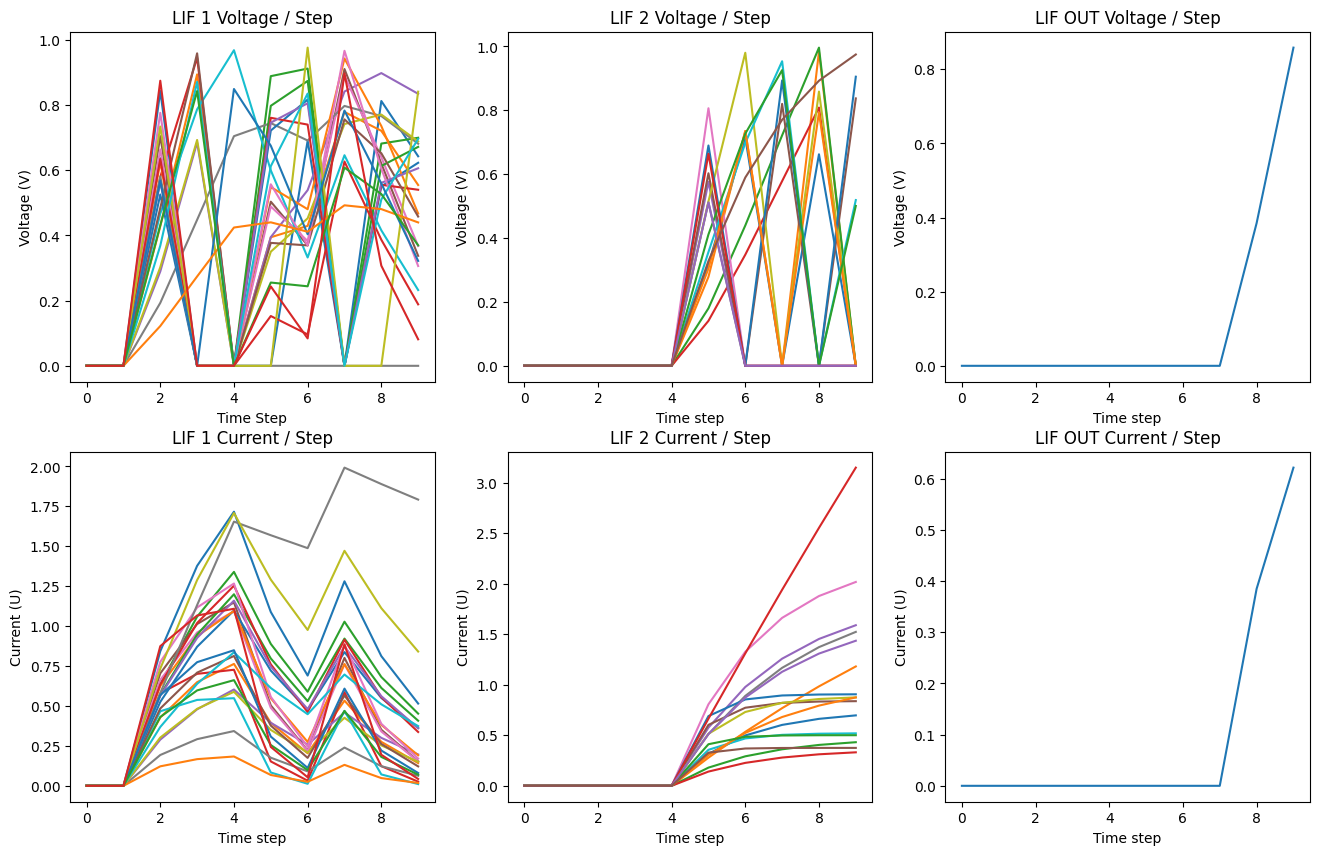

In [33]:
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt

# Create a subplot for each monitored variable
fig = plt.figure(figsize=(16, 10))
ax0 = fig.add_subplot(2, 3, 1)
ax1 = fig.add_subplot(2, 3, 2)
ax2 = fig.add_subplot(2, 3, 3)
ax3 = fig.add_subplot(2, 3, 4)
ax4 = fig.add_subplot(2, 3, 5)
ax5 = fig.add_subplot(2, 3, 6)

# Plot the data
monitor_lif1_v.plot(ax0, lif1.v)
monitor_lif2_v.plot(ax1, lif2.v)
monitor_lif_out_v.plot(ax2, lif_out.v)
monitor_lif1_u.plot(ax3, lif1.u)
monitor_lif2_u.plot(ax4, lif2.u)
monitor_lif_out_u.plot(ax5, lif_out.u)

# Set the Title of each Subplot
ax0.set_xlabel('Time Step')
ax0.set_ylabel('Voltage (V)')
ax0.set_title('LIF 1 Voltage / Step')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('LIF 2 Voltage / Step')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('LIF OUT Voltage / Step')


ax3.set_ylabel('Current (U)')
ax3.set_title('LIF 1 Current / Step')
ax4.set_ylabel('Current (U)')
ax4.set_title('LIF 2 Current / Step')
ax5.set_ylabel('Current (U)')
ax5.set_title('LIF OUT Current / Step')

## Clean up the Network

In [ ]:
# Terminates Process Execution for all Network Nodes
input_layer.stop()